In [4]:
import pandas as pd
data = pd.read_csv('processed/all_years_aggregated.csv')


In [29]:
data.head()

,geo_region,education_grouped,age_group,family_income_grouped,year,weight,time_at_curr_address_-9,time_at_curr_address_-3,time_at_curr_address_-2,time_at_curr_address_1,...,sex_2,race_grouped_PI_only,race_grouped_american_indian_only,race_grouped_asian_only,race_grouped_black_only,race_grouped_multiracial,race_grouped_white_only,did_vote_1,time_at_curr_address_-1,group_id
0,1,associates,18-24,high_income,10,6428960,0.0,0.0,0.0,0.000000,...,0.000000,0.0,1.0,0.0,0.000000,0.0,0.000000,0.000000,NaN,1_associates_18-24_high_income
1,1,associates,18-24,low_income,10,23548114,0.0,0.0,0.0,0.000000,...,0.798776,0.0,0.0,0.0,0.000000,0.0,1.000000,0.201224,NaN,1_associates_18-24_low_income
2,1,associates,18-24,lower_middle_class,10,82249933,0.0,0.0,0.0,0.063818,...,0.805414,0.0,0.0,0.0,0.000000,0.0,1.000000,0.137172,NaN,1_associates_18-24_lower_middle_class
3,1,associates,18-24,middle_class,10,154174030,0.0,0.0,0.0,0.042434,...,0.295308,0.0,0.0,0.0,0.175353,0.0,0.824647,0.226752,NaN,1_associates_18-24_middle_class
4,1,associates,18-24,upper_middle_class,10,73608451,0.0,0.0,0.0,0.000000,...,0.760716,0.0,0.0,0.0,0.000000,0.0,1.000000,0.388938,NaN,1_associates_18-24_upper_middle_class


In [ ]:
#count the number of times that weight is 0 
print(data[data['weight'] == 0].shape[0])
# showing where the weight is 0
print(data[data['weight'] == 0])

# overall total rows and columns
print(data.shape)
weight_zero_df = data[data['weight'] == 0]
# distribution of the different groups where the weight is 0


243
       geo_region     education_grouped age_group family_income_grouped  year  \
95              1  less_than_highschool     25-34           high_income    10   
100             1  less_than_highschool     35-44           high_income    10   
121             1     masters_and_above     18-24            low_income    10   
122             1     masters_and_above     18-24    lower_middle_class    10   
275             2  less_than_highschool     25-34           high_income    10   
...           ...                   ...       ...                   ...   ...   
11281           8     masters_and_above     18-24            low_income    24   
11282           8     masters_and_above     18-24    lower_middle_class    24   
11283           8     masters_and_above     18-24          middle_class    24   
11462           9     masters_and_above     18-24    lower_middle_class    24   
11463           9     masters_and_above     18-24          middle_class    24   

       weight  time_at_

In [ ]:
problematic_groups = (
    weight_zero_df
    .groupby(["education_grouped", "age_group", "family_income_grouped", "geo_region"])
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)

problematic_groups.head(50)

# clear contratdictions - masters and above 18-24 years olds with low income
# or high income and low education 
# not sure its better to manually filter these out 

,education_grouped,age_group,family_income_grouped,geo_region,count
59,masters_and_above,18-24,low_income,8,6
66,masters_and_above,18-24,lower_middle_class,6,6
22,less_than_highschool,35-44,high_income,2,5
15,less_than_highschool,25-34,high_income,4,5
37,less_than_highschool,55-64,high_income,6,5
53,masters_and_above,18-24,low_income,2,5
54,masters_and_above,18-24,low_income,3,5
55,masters_and_above,18-24,low_income,4,5
26,less_than_highschool,35-44,high_income,6,5
58,masters_and_above,18-24,low_income,7,5


In [21]:
# creating group ids to track the demographic groups we've created over time 
data["group_id"] = (
    data["geo_region"].astype(str) + "_" +
    data["education_grouped"].astype(str) + "_" +
    data["age_group"].astype(str) + "_" +
    data["family_income_grouped"].astype(str)
)

In [22]:
grouped = data.groupby(["group_id", "year"]).sum()

In [24]:
grouped = grouped.sort_values(["group_id", "year"])
grouped.head()

,,geo_region,education_grouped,age_group,family_income_grouped,weight,time_at_curr_address_-9,time_at_curr_address_-3,time_at_curr_address_-2,time_at_curr_address_1,time_at_curr_address_2,...,sex_1,sex_2,race_grouped_PI_only,race_grouped_american_indian_only,race_grouped_asian_only,race_grouped_black_only,race_grouped_multiracial,race_grouped_white_only,did_vote_1,time_at_curr_address_-1
group_id,year,,,,,,,,,,,,,,,,,,,,,
0_associates_18-24_high_income,14,0,associates,18-24,high_income,1216753555,0.0,0.0,0.0,0.033570,0.108070,...,0.590727,0.409273,0.000000,0.013051,0.119456,0.000000,0.075209,0.792283,0.330080,0.000000
0_associates_18-24_low_income,14,0,associates,18-24,low_income,2258803297,0.0,0.0,0.0,0.531560,0.263094,...,0.346483,0.653517,0.000000,0.014053,0.015411,0.213782,0.010389,0.746366,0.215966,0.000000
0_associates_18-24_lower_middle_class,14,0,associates,18-24,lower_middle_class,2938295706,0.0,0.0,0.0,0.317561,0.196221,...,0.483805,0.516195,0.007154,0.000000,0.050259,0.196894,0.070866,0.674826,0.263332,0.015718
0_associates_18-24_middle_class,14,0,associates,18-24,middle_class,4082663531,0.0,0.0,0.0,0.250824,0.108004,...,0.383261,0.616739,0.000000,0.008874,0.041140,0.107361,0.050887,0.791738,0.329703,0.018816
0_associates_18-24_upper_middle_class,14,0,associates,18-24,upper_middle_class,3058452326,0.0,0.0,0.0,0.092024,0.142400,...,0.435987,0.564013,0.000000,0.006618,0.013394,0.064713,0.029919,0.885357,0.412350,0.000000


In [31]:
# looking at one group over time for a sanity check 
sample_group = (
    (data["geo_region"] == 1) &
    (data["education_grouped"] == "masters_and_above") &
    (data["age_group"] == "55-64") &
    (data["family_income_grouped"] == "high_income")
)

In [32]:
group_example = data[sample_group]


In [33]:
group_ts = (
    group_example
    .groupby("year")
    .mean(numeric_only=True)
    .reset_index()
    .sort_values("year")
)
print(group_ts[["year", "did_vote_1"]])

   year  did_vote_1
0    10    0.873551
1    12    0.922535
2    16    0.954833
3    18    0.894476
4    20    0.949672
5    22    0.946788
6    24    0.993199


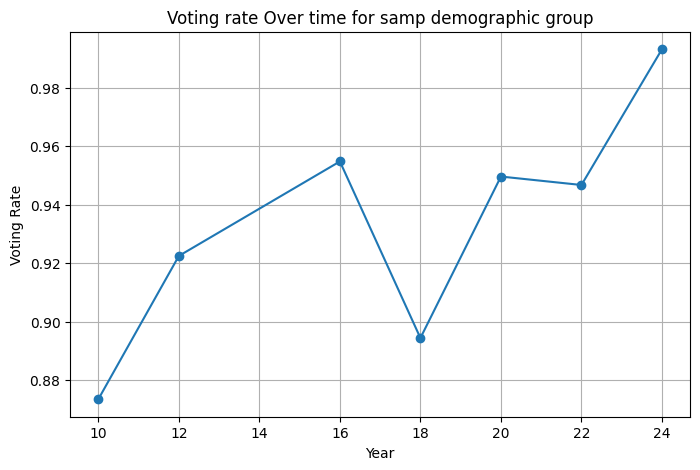

In [36]:
import matplotlib.pyplot as plt
# this is a test of the group id 
# looking at demographic group region 1, masters and above, 55-64 years old, high income

plt.figure(figsize=(8,5))
plt.plot(group_ts["year"], group_ts["did_vote_1"], marker="o")
plt.title("Voting rate Over time for samp demographic group")
plt.xlabel("Year")
plt.ylabel("Voting Rate")
plt.grid(True)
plt.show()

In [48]:
# tracking the group ids over time to see if they are consistent
group_counts = data.groupby("group_id").size().reset_index(name='count')
# sorting by count to see which groups are most common
group_counts = group_counts.sort_values(by='count', ascending=False)
#print(group_counts.head(50))

# group survival rate (we have a group id that persists over all 7 years)
group_survival = (
    data.groupby("group_id")["year"]
    .nunique()
    .reset_index(name='year_count')
)
# percentage of groups that survive all 7 years
num_full_groups = (group_survival["year_count"] == 1).sum()
total_groups = len(group_survival)

percentage = num_full_groups / total_groups

print(percentage)

0.1


In [49]:
# why is there such a high percentage of groups that only appear in one year???????
one_year_groups = group_survival[group_survival["year_count"] == 1]["group_id"]
one_year_data = data[data["group_id"].isin(one_year_groups)]
year_counts = one_year_data["year"].value_counts().sort_index()
print(year_counts)

year
14    180
Name: count, dtype: int64


In [50]:
# problematic year is 2014
df_14 = data[data["year"] == 14]
df_12 = data[data["year"] == 12]
set(df_14["education_grouped"]) - set(df_12["education_grouped"])
cols = ["education_grouped", "age_group", "family_income_grouped", "geo_region"]

for col in cols:
    diff = set(df_14[col]) - set(df_12[col])
    print(f"{col}: {diff}")

education_grouped: set()
age_group: set()
family_income_grouped: set()
geo_region: {0}


In [6]:
#df_14["geo_region"].value_counts()
# soemthing super funky going on in 2014 with the regions 

# reading in the 2014 data to see if there is just an issue in the aggregation 
import pandas as pd
raw_14 = pd.read_csv("clean_data/years/nov14pub_clean.csv")
# value counts of the geo region in the raw data
print(raw_14["GEDIV"].value_counts())

# all of the regions in 2014 are 0, so either need to remove geographic region from the grouping or use states, or skip 2014 entirely

GEDIV
0    80292
Name: count, dtype: int64
